# Modul 08 – Einführung in NumPy, Pandas und Matplotlib

In diesem optionalen Modul lernst du drei sehr wichtige Libraries kennen, die dir im Studium (und darüber hinaus) ständig begegnen werden:

- **NumPy** – effiziente Arrays & numerische Operationen
- **Pandas** – Tabellen / DataFrames für Datenanalyse
- **Matplotlib** – Diagramme zeichnen

Wir bleiben bei Beispielen, die gut zu Medieninformatik passen: einfache **Mediennutzungsdaten** und ein bisschen „Signal-Feeling“.

Voraussetzung: du solltest mit Listen, Dictionaries, Funktionen (Module 03–05) vertraut sein.

## 1. Setup – Libraries importieren

Falls du dieses Notebook im bereitgestellten Kurs-Repo (z. B. in GitHub Codespaces) öffnest, sollten alle Libraries bereits installiert sein.

Wir nutzen die üblichen Kurzformen:

- `numpy` → `np`
- `pandas` → `pd`
- `matplotlib.pyplot` → `plt`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy-Version:", np.__version__)
print("Pandas-Version:", pd.__version__)

NumPy-Version: 2.3.5
Pandas-Version: 2.3.3


## 2. NumPy – Arrays statt Listen

**NumPy-Arrays** sind wie Listen, aber:

- sie sind für numerische Berechnungen optimiert,
- viele Operationen laufen **vektorisiert** (auf einmal, ohne Schleifen im Python-Code),
- sie sind Grundlage für viele weitere Libraries (z. B. Machine Learning).


### 2.1 NumPy-Arrays erstellen

Du kannst Arrays aus Listen bauen oder mit Hilfsfunktionen generieren:

In [2]:
# Array aus Liste
a = np.array([1, 2, 3, 4])
print("a:", a)
print("Typ von a:", type(a))

# arange: Folge ganzer Zahlen
b = np.arange(0, 10, 2)  # start, stop, step
print("b:", b)

# linspace: gleichmäßige Werte zwischen zwei Grenzen
c = np.linspace(0, 1, 5)
print("c:", c)

a: [1 2 3 4]
Typ von a: <class 'numpy.ndarray'>
b: [0 2 4 6 8]
c: [0.   0.25 0.5  0.75 1.  ]


### 2.2 Vektoroperationen

Statt Schleifen nutzen zu müssen kannst du direkt mit ganzen np-Arrays rechnen:

In [3]:
minutes_music = np.array([10, 20, 30, 40])
minutes_video = np.array([5, 15, 25, 35])

total = minutes_music + minutes_video
print("Musik:", minutes_music)
print("Video:", minutes_video)
print("Gesamt:", total)

# Skalierung
double_music = minutes_music * 2
print("Musik verdoppelt:", double_music)

# einfache Statistik
print("Durchschnitt Gesamt:", total.mean())

Musik: [10 20 30 40]
Video: [ 5 15 25 35]
Gesamt: [15 35 55 75]
Musik verdoppelt: [20 40 60 80]
Durchschnitt Gesamt: 45.0


### Mini-Übung NumPy – Normalisierung

Stell dir vor, in `scores` sind Punkte aus einem Spiel gespeichert. Es sind max. 100 Punkte möglich:

```python
scores = np.array([50, 80, 100, 60])
```

Normalisiere sie auf `0–1`, indem du durch 100 teilst. Berechne außerdem den Durchschnitt und gebe die ursprünglichen Scores, die normalisierten Scores und den Durchschnitt aus.

In [ ]:
# TODO: Mini-Übung NumPy – Normalisierung

scores: [ 50  80 100  60]
normalized: [0.5 0.8 1.  0.6]
Durchschnitt (0–1): 0.725


### 2.3 Bonus: Einfacher "Signalverlauf" mit NumPy

Ein klassisches Beispiel: ein **Sinus-Signal**.

Du brauchst dafür:
- einen Zeitvektor `t`
- eine Sinusfunktion `np.sin(...)`

In [5]:
# einfacher Sinus
t = np.linspace(0, 1, 1000)  # 1 Sekunde, 1000 Samples
freq = 5  # 5 Hz
signal = np.sin(2 * np.pi * freq * t)

print("signal (erste 10 Werte):", signal[:10])

signal (erste 10 Werte): [0.         0.03144219 0.06285329 0.09420224 0.12545803 0.15658976
 0.18756665 0.21835807 0.24893355 0.27926288]


## 3. Pandas – Tabellen (DataFrames)

Mit **Pandas** arbeitest du mit tabellarischen Daten, ähnlich wie in Excel oder einer Datenbank.

Zentrales Objekt: der **DataFrame**.

### 3.1 DataFrame aus Dictionary-Liste

Wir bauen eine kleine Tabelle über Mediennutzung:

In [6]:
data = [
    {"user": "Alex", "medium": "Musik", "minutes": 30},
    {"user": "Alex", "medium": "Film", "minutes": 90},
    {"user": "Sam", "medium": "Musik", "minutes": 45},
    {"user": "Riley", "medium": "Game", "minutes": 60},
]

df = pd.DataFrame(data)
df

,user,medium,minutes
0,Alex,Musik,30
1,Alex,Film,90
2,Sam,Musik,45
3,Riley,Game,60


Du kannst:

- Spalten auswählen: `df["minutes"]`
- mehrere Spalten: `df[["user", "minutes"]]`
- filtern: `df[df["medium"] == "Musik"]`

In [7]:
print("Nur die Minuten-Spalte:")
print(df["minutes"])

print("\nNur user + minutes:")
print(df[["user", "minutes"]])

print("\nNur Musik-Sessions:")
print(df[df["medium"] == "Musik"])

Nur die Minuten-Spalte:
0    30
1    90
2    45
3    60
Name: minutes, dtype: int64

Nur user + minutes:
    user  minutes
0   Alex       30
1   Alex       90
2    Sam       45
3  Riley       60

Nur Musik-Sessions:
   user medium  minutes
0  Alex  Musik       30
2   Sam  Musik       45


### 3.2 Gruppieren & Aggregieren

Typische Frage: **Wie viele Minuten pro Nutzer:in?**

Mit `groupby` geht das sehr kompakt:

In [8]:
minutes_per_user = df.groupby("user")["minutes"].sum()
print("Gesamtminuten pro Nutzer: \n", minutes_per_user)

minutes_per_medium = df.groupby("medium")["minutes"].sum()
print("\nGesamtminuten pro Medium: \n", minutes_per_medium)

Gesamtminuten pro Nutzer: 
 user
Alex     120
Riley     60
Sam       45
Name: minutes, dtype: int64

Gesamtminuten pro Medium: 
 medium
Film     90
Game     60
Musik    75
Name: minutes, dtype: int64


### Mini-Übung Pandas – Durchschnittswerte

Berechne mit `groupby`:

- die **durchschnittlichen Minuten pro Nutzer**
- die **durchschnittlichen Minuten pro Medium**

In [ ]:
# TODO: Mini-Übung Pandas – Durchschnittswerte

Durchschnittliche Minuten pro Nutzer:
 user
Alex     60.0
Riley    60.0
Sam      45.0
Name: minutes, dtype: float64

Durchschnittliche Minuten pro Medium:
 medium
Film     90.0
Game     60.0
Musik    37.5
Name: minutes, dtype: float64


### 3.3 Daten aus CSV laden und speichern

Pandas kann super bequem mit CSV-Dateien umgehen.

- `pd.read_csv("pfad.csv")`
- `df.to_csv("pfad.csv", index=False)`

Aber: Bevor wir eine CSV-Datei speichern, müssen wir sicherstellen,  
dass der Zielordner hier: (`data/`) überhaupt existiert.  
Python kann **nicht** in einen Ordner schreiben, der nicht existiert.

Mit dieser Zeile sorgen wir automatisch dafür, dass der Ordner angelegt wird:

```python
from pathlib import Path
Path("data").mkdir(exist_ok=True)
```
Was passiert dabei?
* Path("data") beschreibt den Ordner data/
* .mkdir() legt diesen Ordner an
* exist_ok=True verhindert einen Fehler, falls der Ordner schon existiert

In [12]:
from pathlib import Path
import pandas as pd

# Ordner automatisch erstellen
Path("data").mkdir(exist_ok=True)

# Wir speichern unseren DataFrame zuerst in eine CSV-Datei
df.to_csv("data/media_sessions_example.csv", index=False)
print("CSV gespeichert unter data/media_sessions_example.csv")

# Und lesen sie wieder ein
df_loaded = pd.read_csv("data/media_sessions_example.csv")
df_loaded

CSV gespeichert unter data/media_sessions_example.csv


,user,medium,minutes
0,Alex,Musik,30
1,Alex,Film,90
2,Sam,Musik,45
3,Riley,Game,60


## 4. Matplotlib – einfache Plots

Mit **Matplotlib** kannst du schnell Diagramme erzeugen.

Wir nutzen hier nur Basissachen – weiterführend kannst du später gern mehr erkunden.

### 4.1 Linienplot (z. B. Signal)

Wir verwenden den Sinus aus NumPy (Sektion 2.3) und plotten ihn.

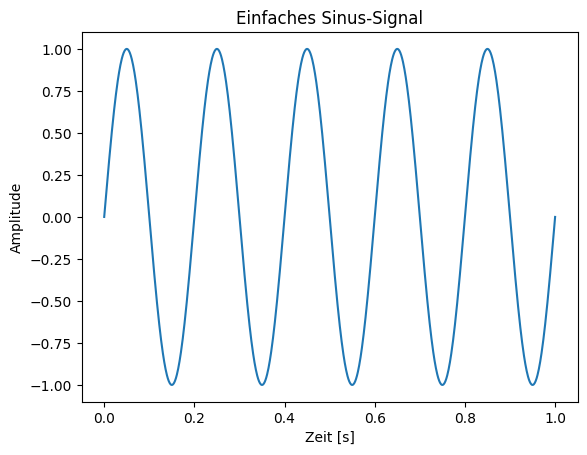

In [13]:
plt.figure()
plt.plot(t, signal)
plt.xlabel("Zeit [s]")
plt.ylabel("Amplitude")
plt.title("Einfaches Sinus-Signal")
plt.show()

### 4.2 Balkendiagramm – Medienminuten

Wir verwenden die Gruppierung aus Pandas (`minutes_per_medium`) und machen ein Balkendiagramm.

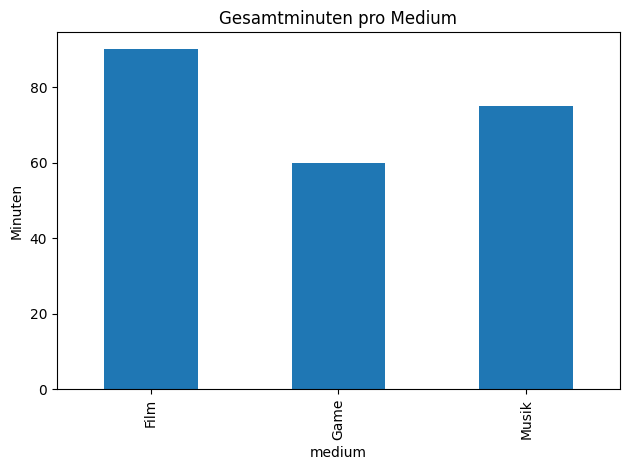

In [14]:
plt.figure()
minutes_per_medium.plot(kind="bar")
plt.ylabel("Minuten")
plt.title("Gesamtminuten pro Medium")
plt.tight_layout()
plt.show()

### Mini-Übung Matplotlib – Nutzer-Ranking visualisieren

Erzeuge aus `minutes_per_user` ein Balkendiagramm.

Idee:

```python
plt.figure()
minutes_per_user.plot(kind="bar")
...
plt.show()
```

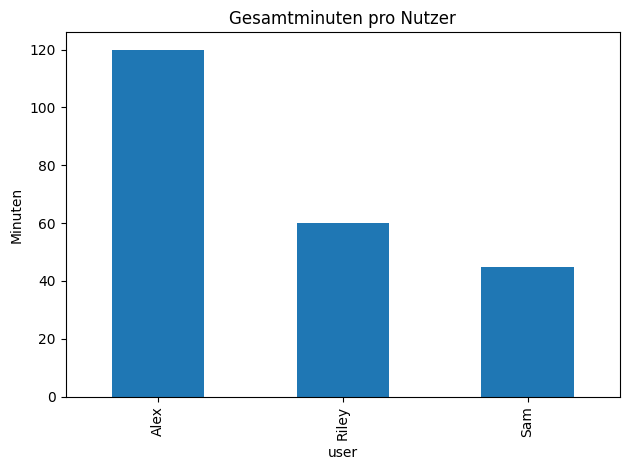

In [ ]:
# TODO: Mini-Übung Matplotlib – Nutzer-Ranking

## 5. Mini-Projekt – Wochenreport Mediennutzung

Stell dir vor, du hast eine CSV-Datei mit Mediennutzung über eine Woche, z. B.:

```text
user,medium,minutes
Alex,Musik,30
Alex,Game,45
Sam,Film,120
Riley,Musik,60
Riley,Film,30
```

Aufgabenidee:

1. CSV mit Pandas laden (z. B. `pd.read_csv("data/media_week.csv")`).
2. Gesamtminuten pro Nutzer berechnen.
3. Gesamtminuten pro Medium berechnen.
4. Zwei Balkendiagramme zeichnen:
   - Nutzer-Ranking
   - Medien-Ranking

Wenn du möchtest, kannst du zusätzlich:

- ausrechnen, wie viel Prozent der Gesamtzeit auf jedes Medium entfällt,
- in NumPy Arrays umsteigen und dort einfache Berechnungen machen.


In [ ]:
# TODO: Mini-Projekt – Wochenreport
# Hinweis: Du musst vorher eine passende CSV anlegen, z. B. data/media_week.csv
# und sicher stellen, dass der Ordner data/ existiert (siehe Aufgabe 3.3)

Hinweis: Datei data/media_week.csv nicht gefunden. Lege sie an, um das Mini-Projekt auszuprobieren.


---
## 6. Zusammenfassung

In diesem Modul hast du gesehen:

- wie du mit **NumPy** Arrays erstellst und vektorisiert rechnest,
- wie du mit **Pandas** tabellarische Daten (DataFrames) analysierst,
- wie du mit **Matplotlib** einfache Diagramme zeichnest,
- wie sich alle drei Libraries zu einem kleinen **Daten-Mini-Projekt** kombinieren lassen.

Damit hast du eine gute Basis für viele spätere Themen:

- Datenanalyse
- Machine Learning / KI
- Auswertung von Nutzungsdaten in Medienprojekten
- kleine Dashboards oder Reports

Dieses Modul ist **optional**, aber sehr empfehlenswert, wenn du in Projekte gehst,
in denen Daten im Mittelpunkt stehen.